**Axon Merging - Suite2p Pipeline**

Merges correlated axonal ROIs from suite2p output by grouping and averaging their dF/F traces.  
Assumes ROI identification/filtering (`Axon_Identification_Merge_Suite2p.ipynb`) has already been run  
and `iscell.npy` reflects the filtered ROIs.

In [23]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats
import os
import itertools
from collections import defaultdict

%cd "C:\Users\jasmineyeo\Documents\GitHub\V1_SpatialModulation"
from helper import axons
from helper.correlation import corr2_coeff
from helper.twop import TwoP
from helper.files import write_h5



# ============================================================================
# CONFIGURATION
# ============================================================================
suite2p_path = r"D:\V1_SpatialModulation\2p\V1_window\JSY061_ChronicImaging_Axonal\260209_JSY_JSY061_SpMod_AxonalImaging_OpenLoopVR\TSeries-02092026-1620-001\suite2p\plane0"


save_path = os.path.join(suite2p_path, 'axon_merged_output.h5')

twop_rate = 10.047       # imaging frame rate (Hz)
neu_correction = 0.7   # neuropil correction factor
cc_thresh = 0.25       # pairwise correlation threshold for merging
max_distance = 15      # max centroid distance (pixels) to allow merging
merge_duplicates = True  # True = average correlated groups, False = drop weaker of pair


C:\Users\jasmineyeo\Documents\GitHub\V1_SpatialModulation


In [24]:
# ============================================================================
# LOAD SUITE2P DATA AND COMPUTE dF/F
# ============================================================================

# Load suite2p files
F = np.load(os.path.join(suite2p_path, 'F.npy'))
Fneu = np.load(os.path.join(suite2p_path, 'Fneu.npy'))
iscell = np.load(os.path.join(suite2p_path, 'iscell.npy'))
stat = np.load(os.path.join(suite2p_path, 'stat.npy'), allow_pickle=True)
ops = np.load(os.path.join(suite2p_path, 'ops.npy'), allow_pickle=True).item()

# Filter by iscell (assumes ROI identification has already been run)
cell_mask = iscell[:, 0] == 1
F_cells = F[cell_mask, :]
Fneu_cells = Fneu[cell_mask, :]
stat_cells = stat[cell_mask]
original_indices = np.where(cell_mask)[0]  # maps filtered idx -> original ROI idx

print(f"Total ROIs: {len(stat)}")
print(f"Cells after iscell filter: {F_cells.shape[0]}")
print(f"Frames: {F_cells.shape[1]}")

# Compute dF/F with neuropil correction (same method as helper/twop.py TwoP.calc_dFF)
nCells, lenT = F_cells.shape
dFF = np.zeros((nCells, lenT))

for c in range(nCells):
    F_cell = F_cells[c, :].copy()
    F_neu = Fneu_cells[c, :].copy()

    # Neuropil subtraction
    norm_F = F_cell - neu_correction * F_neu + neu_correction * np.nanmean(F_neu)

    # Baseline estimation (mode)
    F0 = scipy.stats.mode(norm_F, nan_policy='omit').mode

    # dF/F (%)
    dFF[c, :] = (norm_F - F0) / F0 * 100

# Mean fluorescence across all ROIs per frame (proxy for global frame fluorescence)
frame_means = np.mean(F_cells, axis=0)

print(f"\ndF/F computed: {dFF.shape}")

Total ROIs: 1630
Cells after iscell filter: 418
Frames: 22378

dF/F computed: (418, 22378)


In [25]:
# ============================================================================
# RUN AXON MERGING (with spatial distance constraint)
# ============================================================================
# Reimplements the grouping logic from helper/axons.py but adds a
# max_distance criterion: two ROIs must be BOTH temporally correlated
# (cc > cc_thresh) AND spatially close (centroid distance < max_distance)
# to be linked. This prevents the connected-components chaining problem
# where distant but co-tuned axons get merged into giant groups.

# Get ROI centroids from suite2p stat
centroids = np.array([s['med'] for s in stat_cells])  # (nCells, 2) = (y, x)

# Compute pairwise correlations
perm_mat = np.array(list(itertools.combinations(range(nCells), 2)))
cc_vec = np.zeros(len(perm_mat))
for i in range(len(perm_mat)):
    cc_vec[i] = corr2_coeff(
        dFF[perm_mat[i, 0]][np.newaxis, :],
        dFF[perm_mat[i, 1]][np.newaxis, :]
    )

# Build adjacency graph with BOTH correlation AND distance constraints
adjacency = defaultdict(set)
n_corr_only = 0
n_corr_and_close = 0

for idx in range(len(perm_mat)):
    if cc_vec[idx] > cc_thresh:
        n_corr_only += 1
        a, b = perm_mat[idx]
        dist = np.sqrt(np.sum((centroids[a] - centroids[b]) ** 2))
        if dist < max_distance:
            n_corr_and_close += 1
            adjacency[a].add(b)
            adjacency[b].add(a)

print(f"Pairs above cc_thresh ({cc_thresh}): {n_corr_only}")
print(f"Pairs also within max_distance ({max_distance} px): {n_corr_and_close}")

# Find connected components
visited = set()
kept_groups = []
for node in range(nCells):
    if node not in visited:
        stack = [node]
        group = set()
        while stack:
            n = stack.pop()
            if n not in visited:
                visited.add(n)
                group.add(n)
                stack.extend(adjacency[n] - visited)
        kept_groups.append(sorted(list(group)))

# Average traces within each group
averaged_traces = []
for group in kept_groups:
    averaged_traces.append(np.mean(dFF[group, :], axis=0))
dFF_merged = np.array(averaged_traces)

# Denoise and infer spikes
denoised_dFF, spikes = TwoP.calc_inf_spikes(dFF_merged, fps=twop_rate)

n_original = nCells
n_merged = dFF_merged.shape[0]
n_multi_groups = sum(1 for g in kept_groups if len(g) > 1)
removed_filtered_indices = set()  # no gcc removal
n_gcc_removed = 0

print(f"\nOriginal axons: {n_original}")
print(f"After merging: {n_merged} independent axons")
print(f"Groups with >1 axon merged: {n_multi_groups}")
# print(f"Axons in multi-groups: {sum(len(g) for g in kept_groups 

Pairs above cc_thresh (0.25): 14688
Pairs also within max_distance (15 px): 74

Original axons: 418
After merging: 348 independent axons
Groups with >1 axon merged: 47


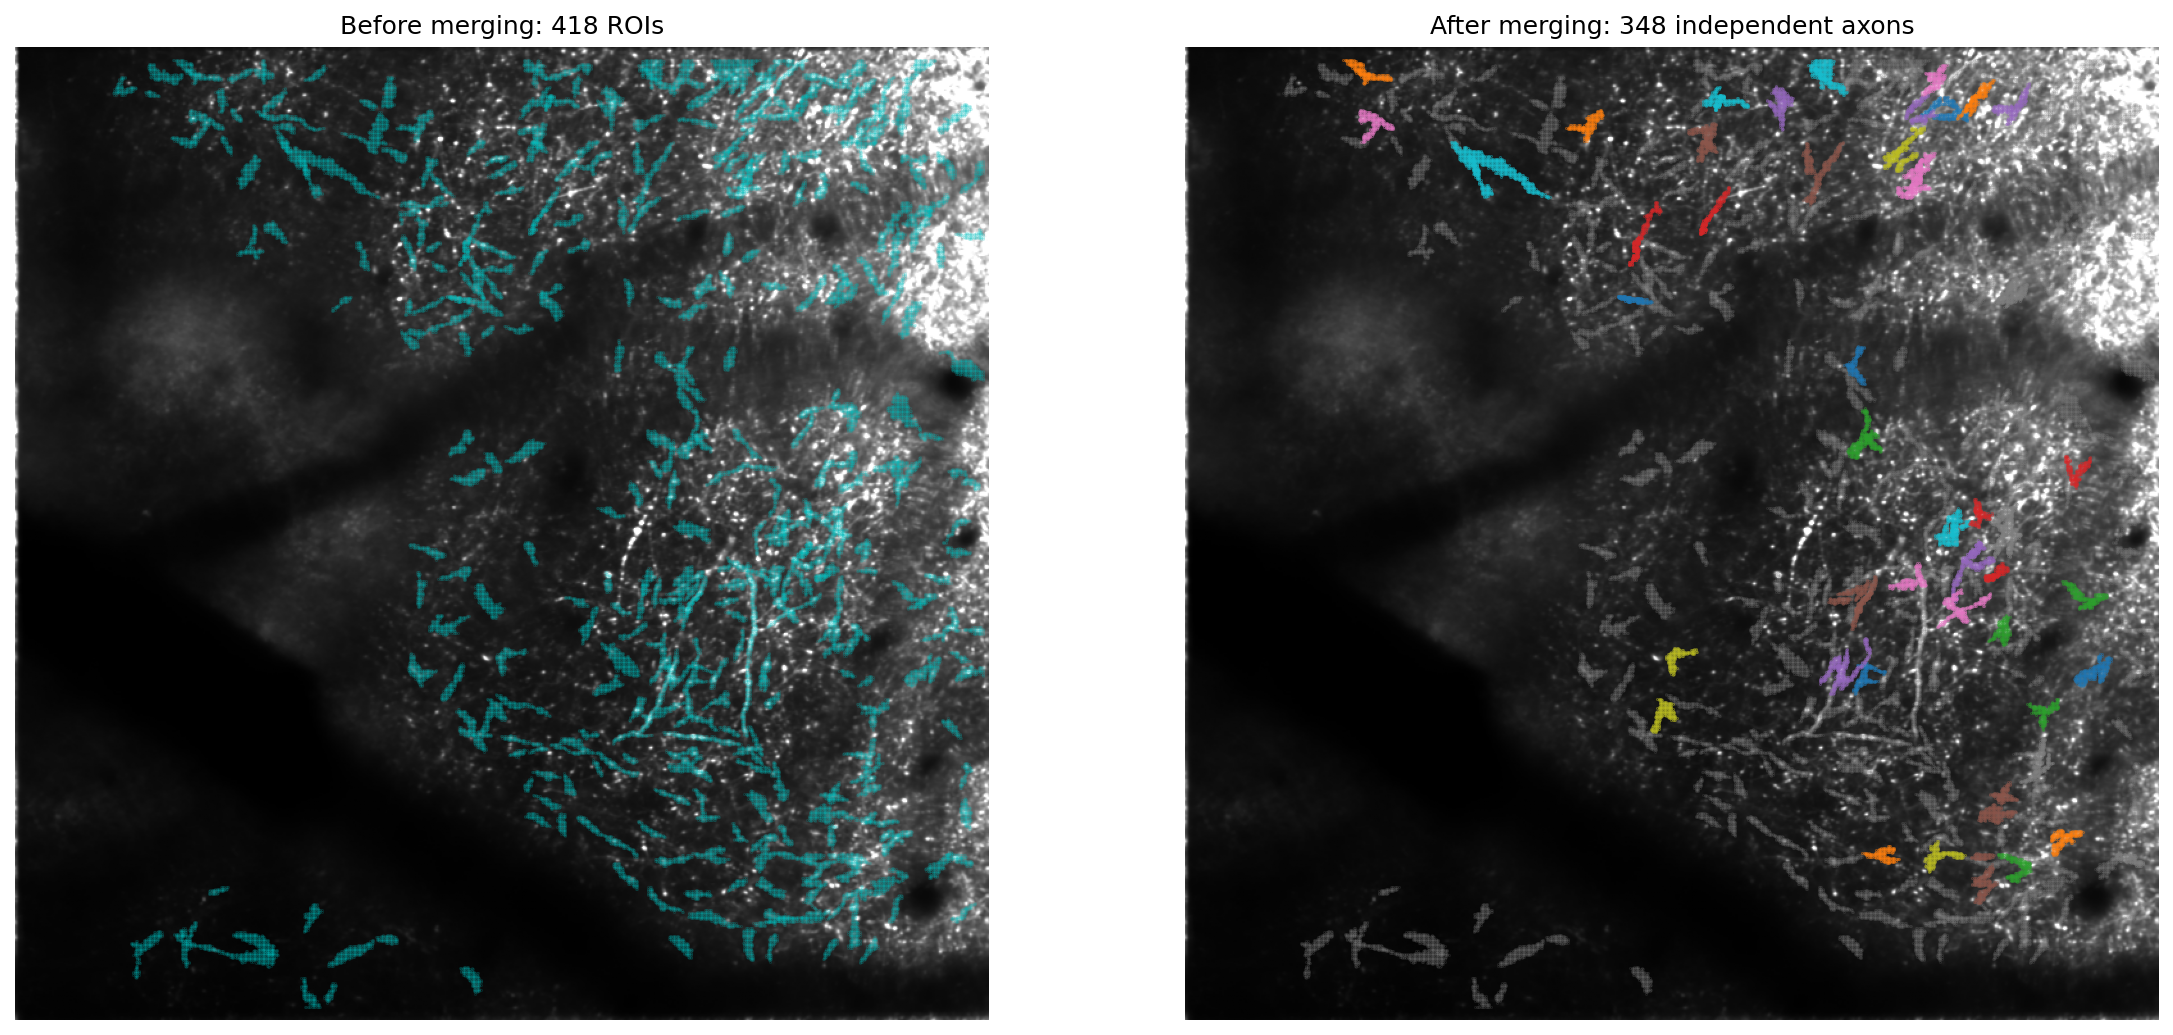

In [26]:
# ============================================================================
# VISUALIZE MERGED GROUPS ON MEAN IMAGE
# ============================================================================

mean_img = ops.get('meanImg', np.zeros((ops['Ly'], ops['Lx'])))

fig, axes = plt.subplots(1, 2, figsize=(16, 7), dpi=150)

# Left: all ROIs before merging
ax = axes[0]
ax.imshow(mean_img, cmap='gray',
          vmin=np.percentile(mean_img, 1), vmax=np.percentile(mean_img, 99))
for i in range(len(stat_cells)):
    ypix = stat_cells[i]['ypix']
    xpix = stat_cells[i]['xpix']
    ax.plot(xpix, ypix, 'c.', ms=0.3, alpha=0.5)
ax.set_title(f'Before merging: {n_original} ROIs')
ax.axis('off')

# Right: after merging - single groups in gray, multi groups in color
ax = axes[1]
ax.imshow(mean_img, cmap='gray',
          vmin=np.percentile(mean_img, 1), vmax=np.percentile(mean_img, 99))

# Single-axon groups in gray
for gi, g in enumerate(kept_groups):
    if len(g) == 1:
        idx = g[0] if isinstance(g, list) else g
        ypix = stat_cells[idx]['ypix']
        xpix = stat_cells[idx]['xpix']
        ax.plot(xpix, ypix, '.', color='gray', ms=0.3, alpha=0.5)

# Multi-axon groups in distinct colors
cmap = plt.cm.tab10
color_idx = 0
for gi, g in enumerate(kept_groups):
    if len(g) > 1:
        color = cmap(color_idx % 10)
        color_idx += 1
        for gx in g:
            ypix = stat_cells[gx]['ypix']
            xpix = stat_cells[gx]['xpix']
            ax.plot(xpix, ypix, '.', color=color, ms=0.5, alpha=0.8)

ax.set_title(f'After merging: {n_merged} independent axons')
ax.axis('off')

plt.tight_layout()
plt.show()

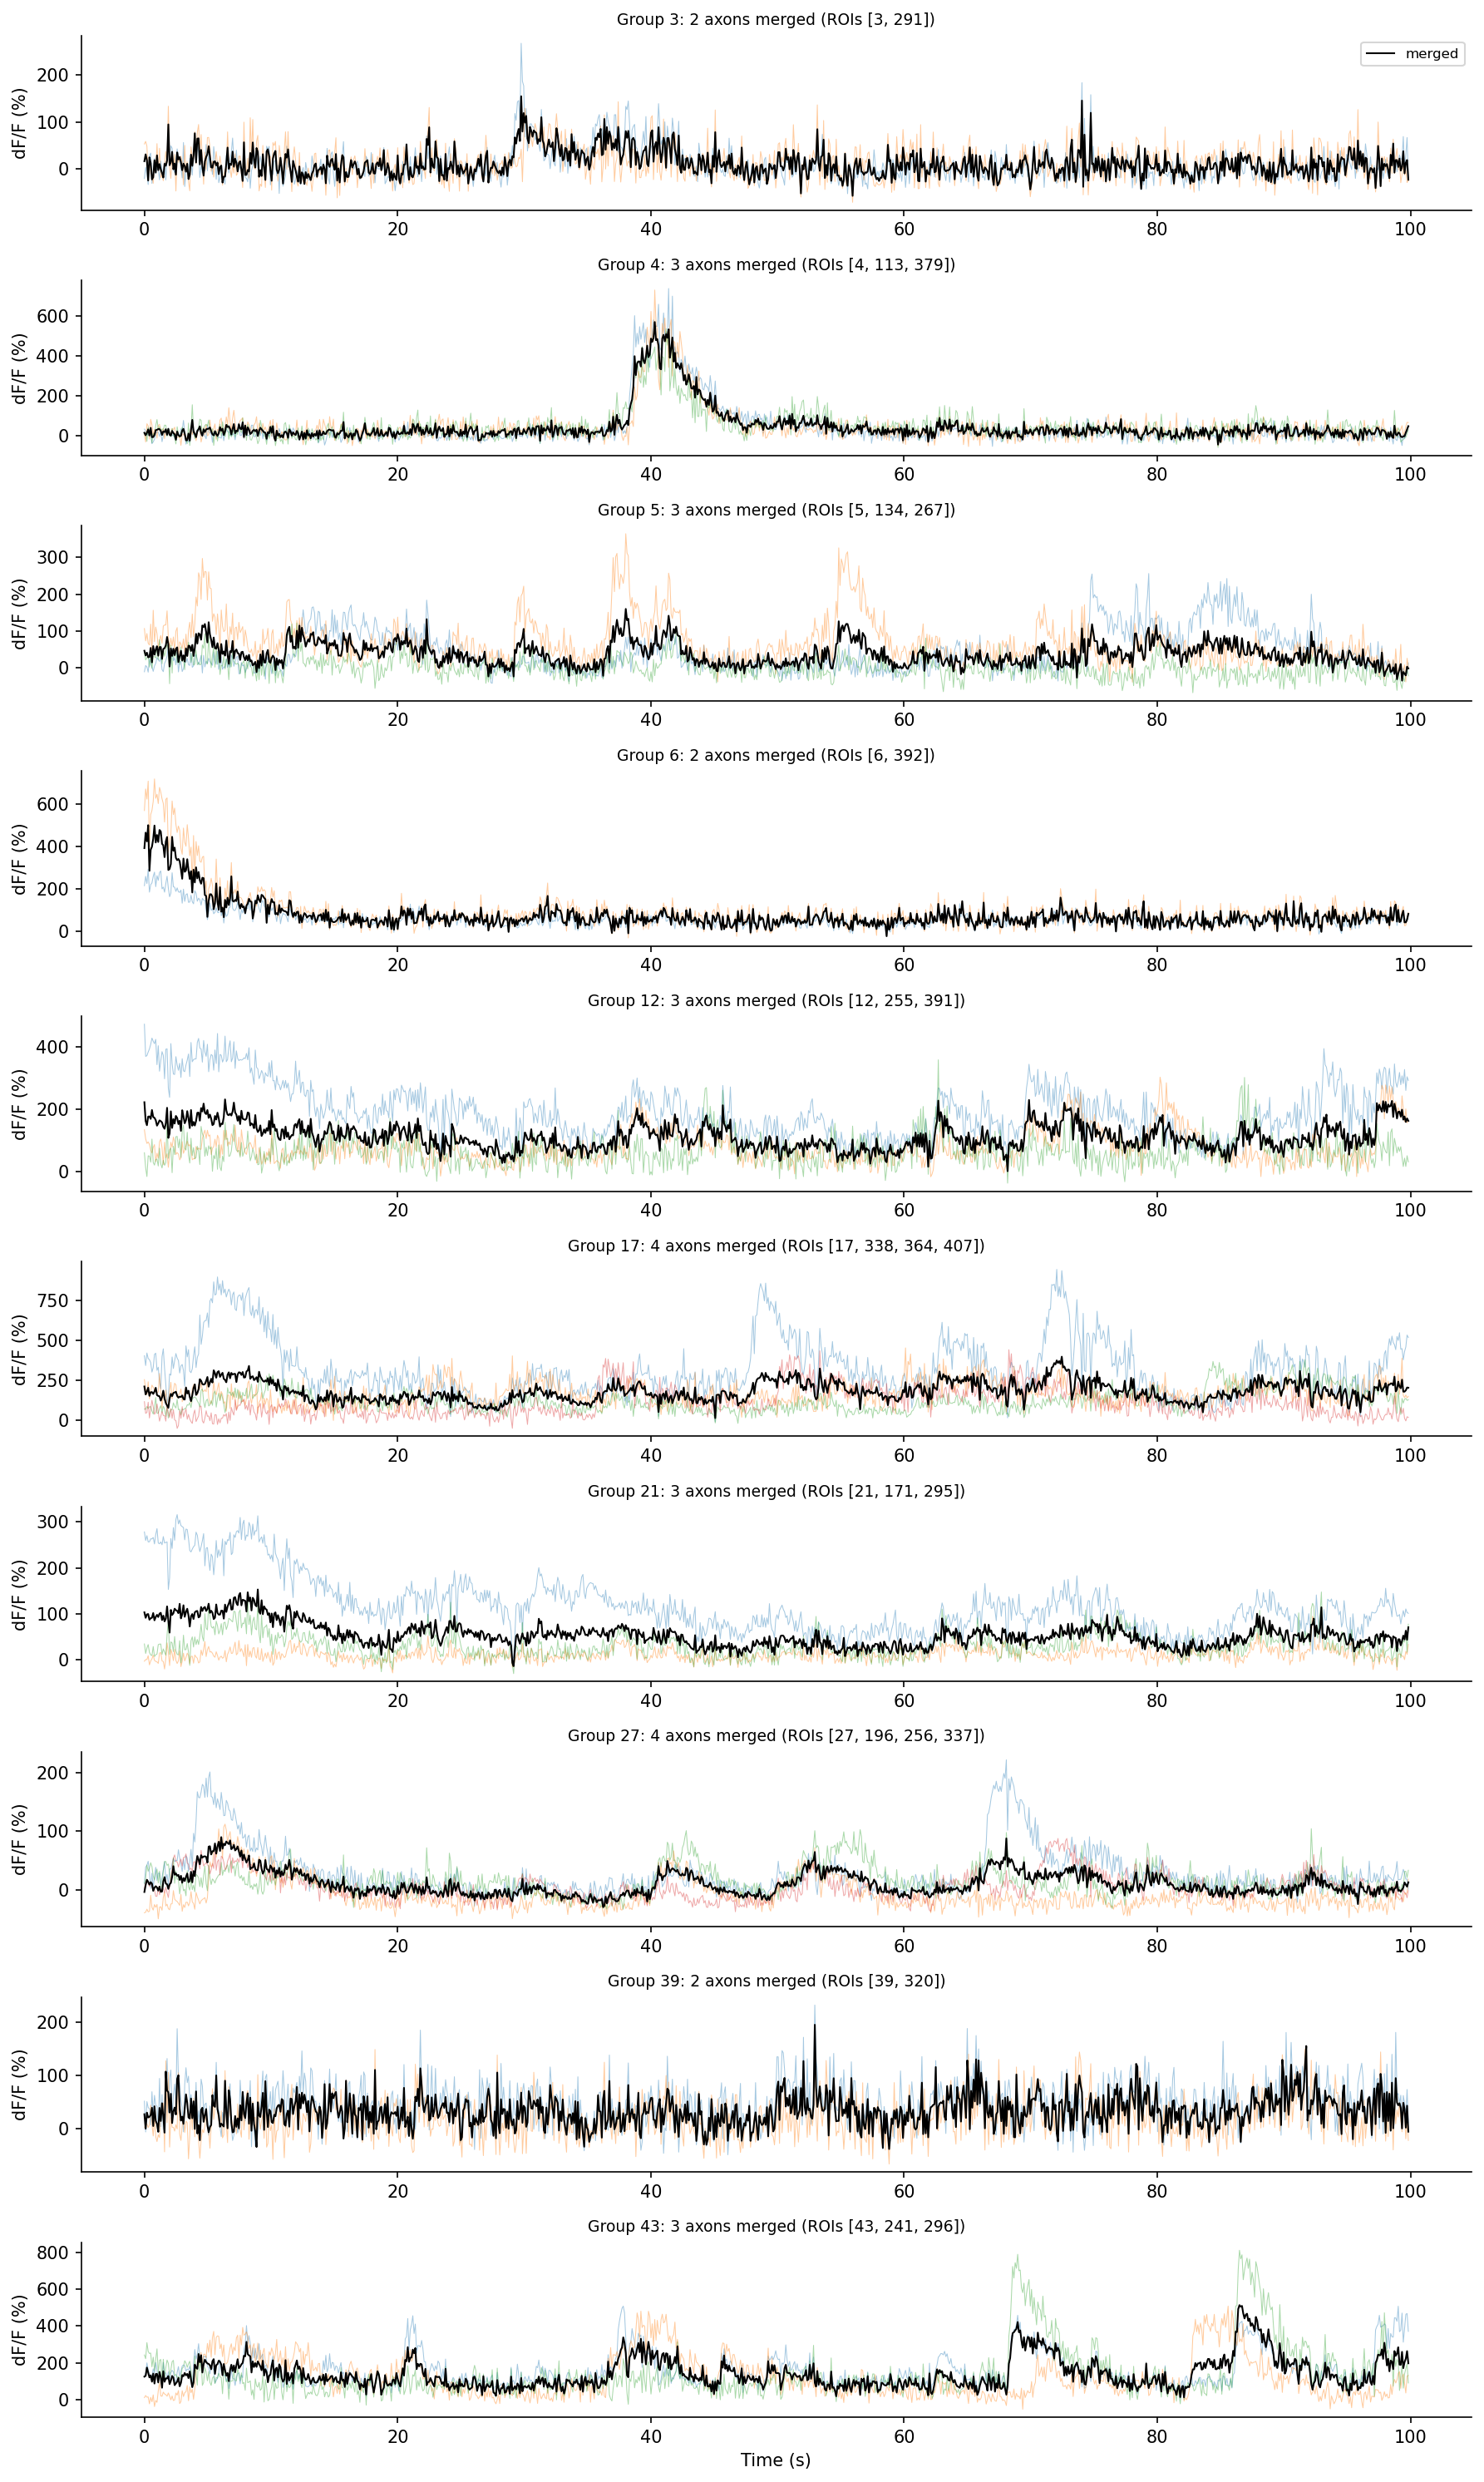

In [27]:
# ============================================================================
# PLOT TRACES OF MERGED GROUPS
# ============================================================================

multi_groups = [(gi, g) for gi, g in enumerate(kept_groups) if len(g) > 1]
# n_show = len(multi_groups)
n_show = min(10, len(multi_groups))

if n_show > 0:
    fig, axes = plt.subplots(n_show, 1, figsize=(12, 2 * n_show), dpi=150)
    if n_show == 1:
        axes = [axes]

    # Show first 100 seconds
    n_frames_show = min(int(100 * twop_rate), lenT)
    time = np.arange(n_frames_show) / twop_rate

    for i, (gi, g) in enumerate(multi_groups[:n_show]):
        ax = axes[i]
        # Individual traces (transparent)
        for gx in g:
            ax.plot(time, dFF[gx, :n_frames_show], alpha=0.4, lw=0.5)
        # Merged trace (black)
        ax.plot(time, dFF_merged[gi, :n_frames_show], 'k-', lw=1, label='merged')
        ax.set_ylabel('dF/F (%)')
        ax.set_title(f'Group {gi}: {len(g)} axons merged (ROIs {g})', fontsize=9)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        if i == 0:
            ax.legend(fontsize=8)

    axes[-1].set_xlabel('Time (s)')
    plt.tight_layout()
    plt.show()
else:
    print("No multi-axon groups found with current thresholds.")

In [28]:
# ============================================================================
# UPDATE ISCELL.NPY
# ============================================================================
# For each merged group, keep the ROI with highest integrated dF/F as the
# representative and set the others to iscell=0. Single-axon groups are unchanged.
# This way suite2p GUI shows one ROI per independent axon.

iscell_premerge_path = os.path.join(suite2p_path, 'iscell_premerge.npy')
iscell_path = os.path.join(suite2p_path, 'iscell.npy')

# Backup
if not os.path.exists(iscell_premerge_path):
    np.save(iscell_premerge_path, iscell)
    print(f"Backup saved: {iscell_premerge_path}")
else:
    print(f"Backup already exists: {iscell_premerge_path}")

# For each multi-axon group, keep the ROI with highest integrated dF/F
iscell_updated = iscell.copy()
n_removed = 0

for g in kept_groups:
    if len(g) > 1:
        # Find the ROI with highest integrated dF/F in this group
        integrated = [np.sum(dFF[idx, :]) for idx in g]
        best_idx = g[np.argmax(integrated)]
        # Set all others in this group to iscell=0
        for idx in g:
            if idx != best_idx:
                orig_idx = original_indices[idx]
                iscell_updated[orig_idx, 0] = 0
                n_removed += 1

np.save(iscell_path, iscell_updated)

n_before = int(np.sum(iscell[:, 0] == 1))
n_after = int(np.sum(iscell_updated[:, 0] == 1))

print(f"\niscell updated:")
print(f"  Before: {n_before} cells")
print(f"  After:  {n_after} cells  (= {n_merged} independent axons)")
print(f"  Removed (redundant members of merged groups): {n_removed}")
print(f"\nSaved to: {iscell_path}")
print(f"Open suite2p GUI to review the surviving ROIs.")

Backup saved: D:\V1_SpatialModulation\2p\V1_window\JSY061_ChronicImaging_Axonal\260209_JSY_JSY061_SpMod_AxonalImaging_OpenLoopVR\TSeries-02092026-1620-001\suite2p\plane0\iscell_premerge.npy

iscell updated:
  Before: 418 cells
  After:  348 cells  (= 348 independent axons)
  Removed (redundant members of merged groups): 70

Saved to: D:\V1_SpatialModulation\2p\V1_window\JSY061_ChronicImaging_Axonal\260209_JSY_JSY061_SpMod_AxonalImaging_OpenLoopVR\TSeries-02092026-1620-001\suite2p\plane0\iscell.npy
Open suite2p GUI to review the surviving ROIs.
